# Lab 4

## Dataset

Dataset originally available on [Kaggle](https://www.kaggle.com/shivamb/netflix-shows?select=netflix.csv) distributed through [TidyTuesday](https://github.com/rfordatascience/tidytuesday/blob/master/data/2021/2021-04-20/readme.md), published in March 2021.

Columns:

| variable     | type     | description                                      |
|:-------------|:---------|:-------------------------------------------------|
| show_id      | str      | Unique ID for every Movie / TV Show              |
| type         | str      | Identifier - A Movie or TV Show                  |
| title        | str      | Title of the Movie / TV Show                     |
| director     | str      | Director of the Movie/Show                       |
| cast         | str      | Actors involved in the movie / show              |
| country      | str      | Country where the movie / show was produced      |
| date_added   | datetime | Date it was added on Netflix                     |
| release_year | int      | Actual Release year of the movie / show          |
| rating       | category | TV Rating of the movie / show                    |
| duration     | str      | Total Duration - in minutes or number of seasons |
| listed_in    | str      | Genre                                            |
| description  | str      | Summary description of the film/show             |



##

## Tools

- Pandas
- Plotnine

In [244]:
import pandas as pd
from plotnine import *

netflix = pd.read_csv('netflix_titles.csv')

netflix['date_added'] = pd.to_datetime(netflix['date_added'], errors='coerce')

netflix.info()

<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7787 non-null   str           
 1   type          7787 non-null   str           
 2   title         7787 non-null   str           
 3   director      5398 non-null   str           
 4   cast          7069 non-null   str           
 5   country       7280 non-null   str           
 6   date_added    7689 non-null   datetime64[us]
 7   release_year  7787 non-null   int64         
 8   rating        7780 non-null   str           
 9   duration      7787 non-null   str           
 10  listed_in     7787 non-null   str           
 11  description   7787 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 730.2 KB


## Distribution of titles by release year

Compute the counts of titles released by `release_year` and show the distribution using a line

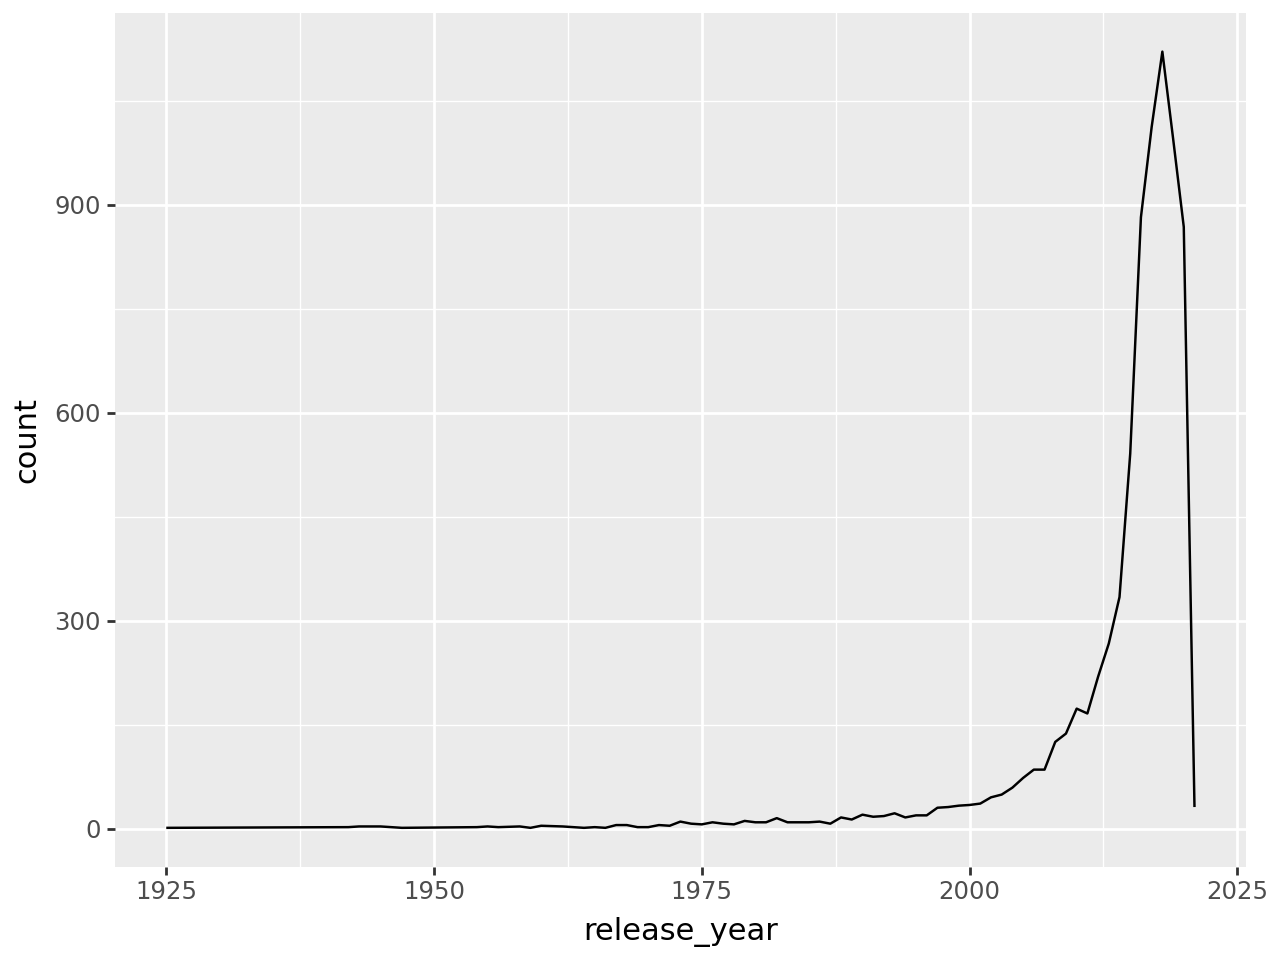

In [245]:
year_counts = netflix["release_year"].value_counts().reset_index()
(
    ggplot(year_counts, aes(x="release_year",y="count"))
    +geom_line()
)

Try with points

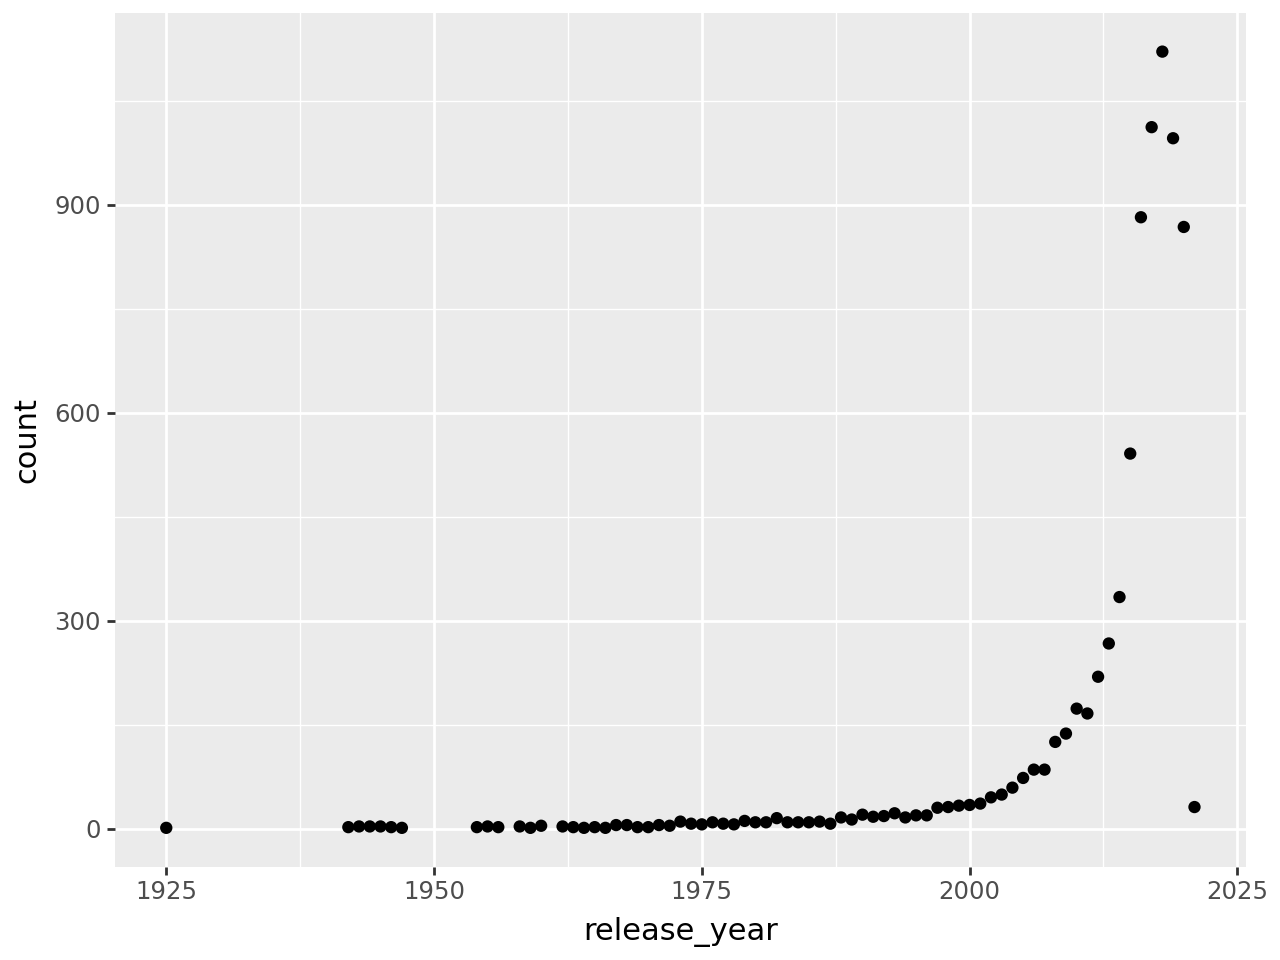

In [246]:
ggplot(year_counts, aes(x="release_year",y="count")) + geom_point()

Let the plotnine library compute the stats by using an count-based bar chart (`geom_bar`)

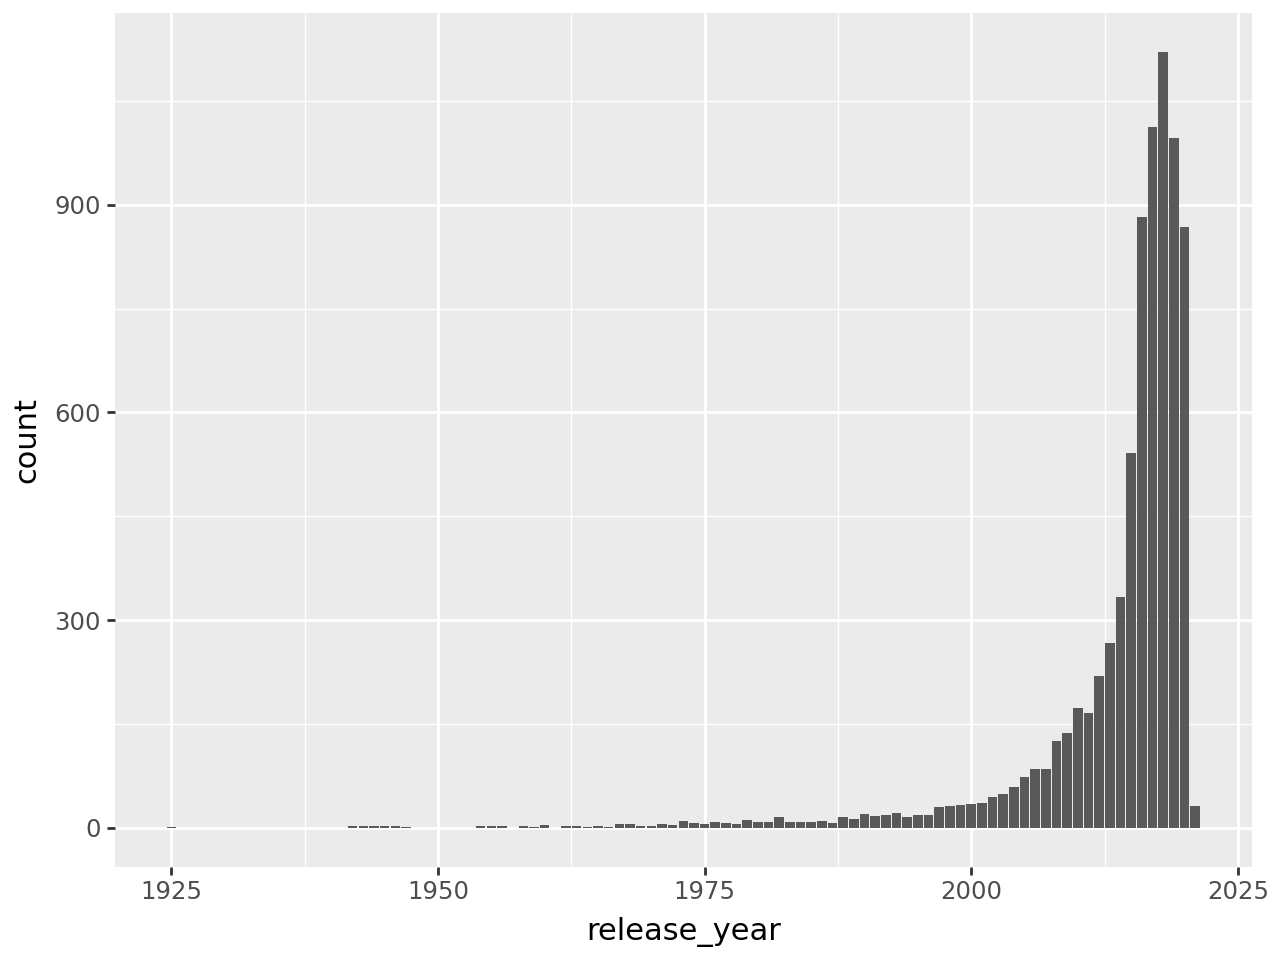

In [247]:
ggplot(netflix, aes(x="release_year")) + geom_bar()

Try using an histogram instead of a bar chart.

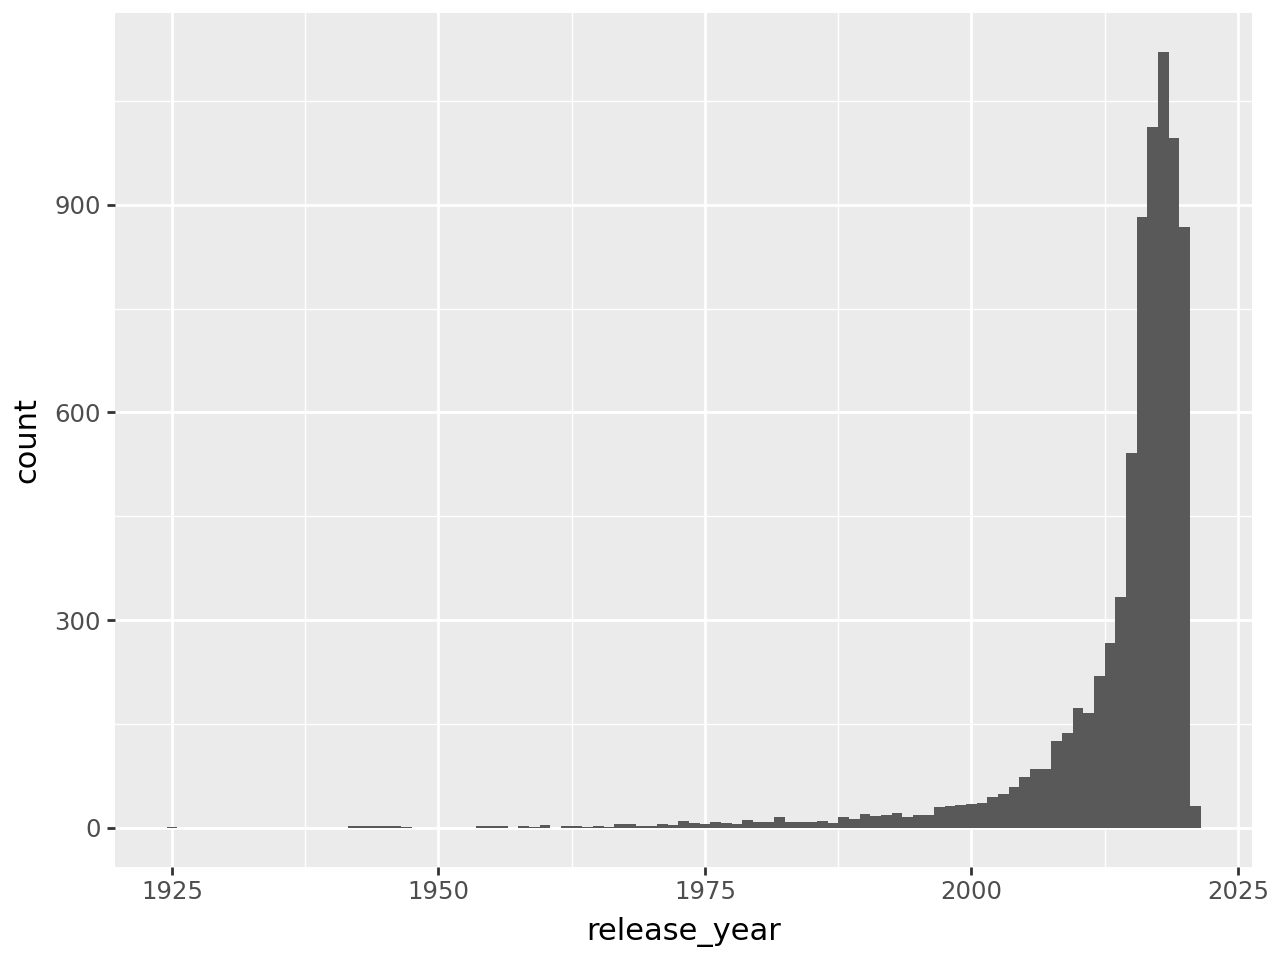

In [248]:
ggplot(netflix, aes(x="release_year")) + geom_histogram(binwidth=1)

Set the `binwidth` parameter of the histogram to e.g. `5`

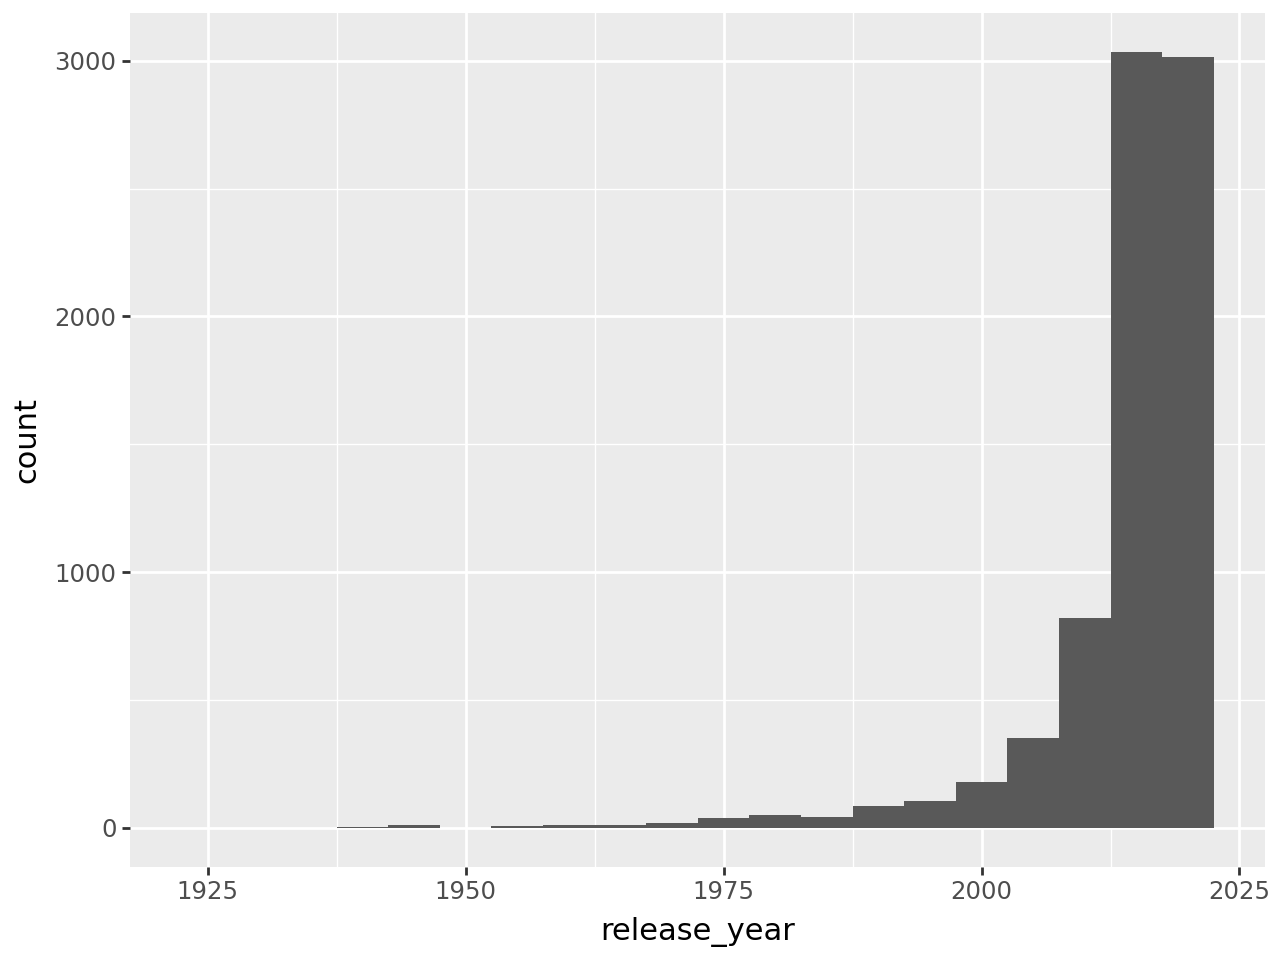

In [249]:
ggplot(netflix, aes(x="release_year")) + geom_histogram(binwidth=5)

## By decade

Show the number of titles by decade of release, you can use a `geom_col`

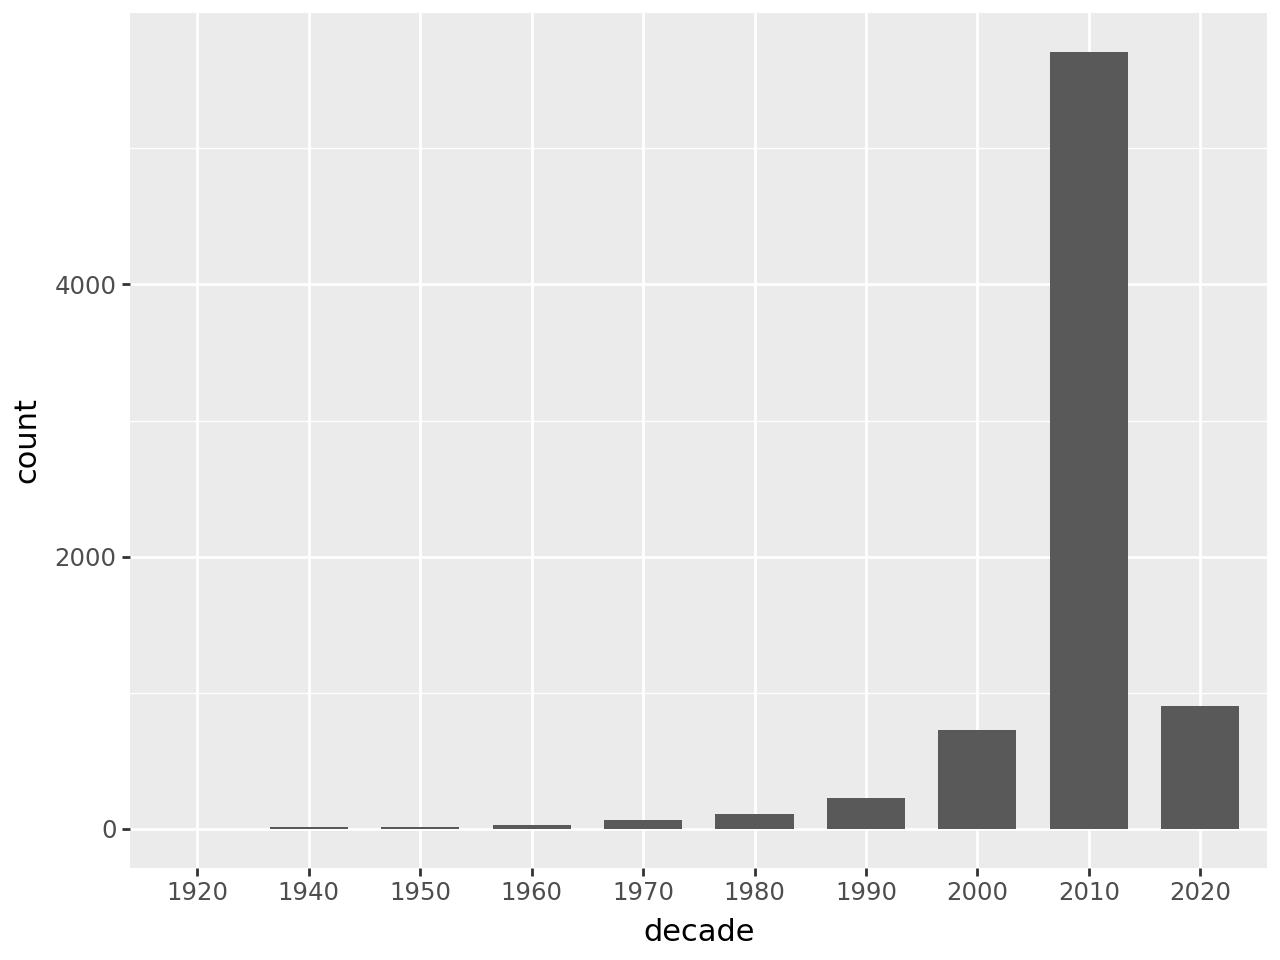

In [250]:
netflix_decade = netflix.assign(decade = lambda x: x["release_year"]//10*10)
count_per_decade = netflix_decade["decade"].value_counts().reset_index()
count_per_decade["decade"] = count_per_decade["decade"].astype("category")

ggplot(count_per_decade, aes(x="decade",y="count")) + geom_col(width=0.7)

Since the latest decade (2020-2029) is not complete yet, it is possible to compute the year average in each decate to get numbers that are comparable

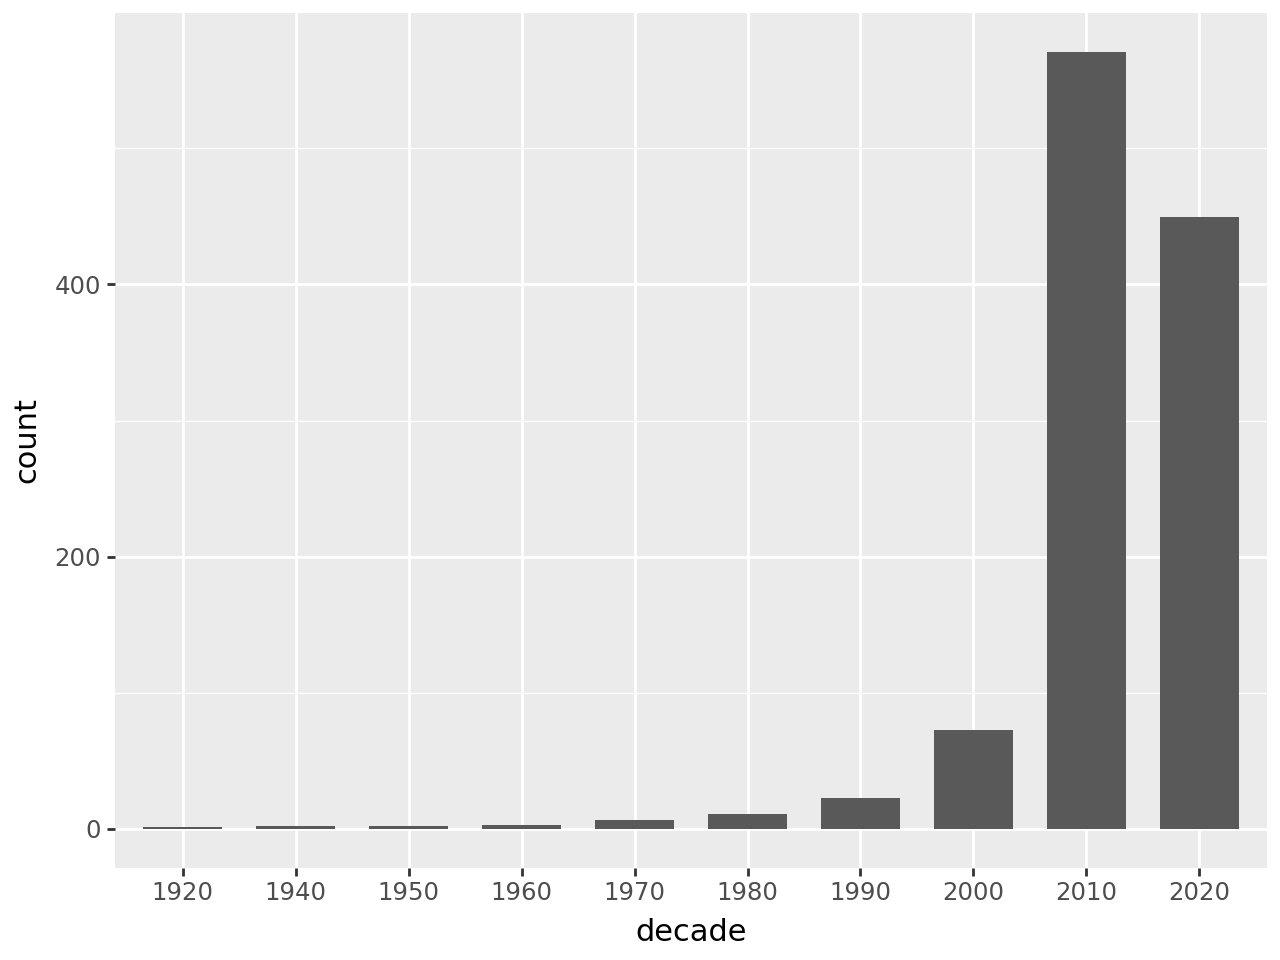

In [251]:
count_per_year = netflix["release_year"].value_counts().reset_index()
count_per_year = count_per_year.assign(decade = lambda x: x["release_year"]//10*10)
avg_per_decade = count_per_year.groupby(by = "decade").agg({"count":"mean"}).reset_index()
avg_per_decade["decade"] = avg_per_decade["decade"].astype("category")

ggplot(avg_per_decade, aes(x="decade",y="count")) + geom_col(width=0.7)

## Distribution by Date Added

Show the number of titles added by `date_added` using points.

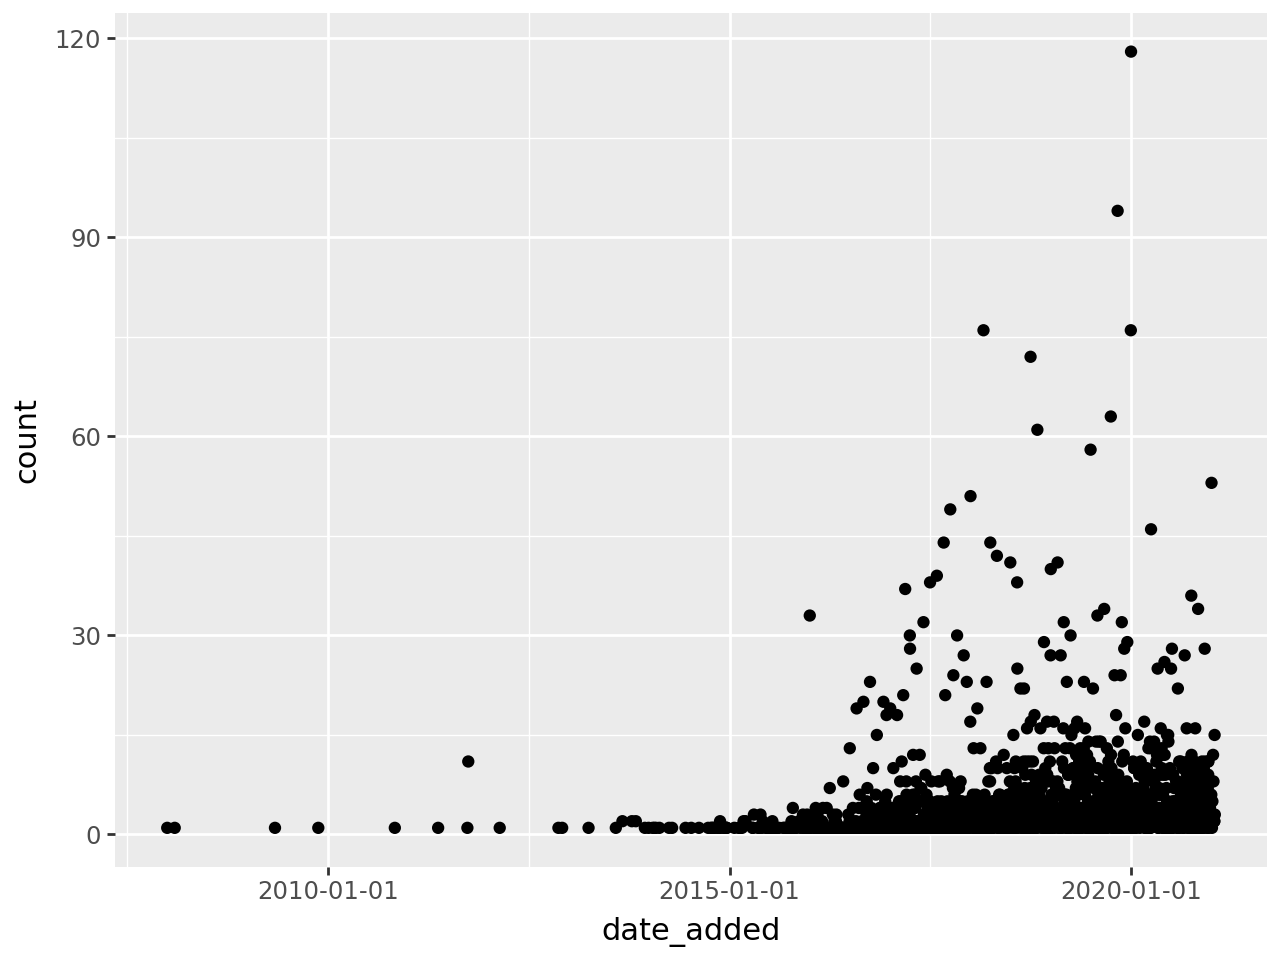

In [252]:
count_per_date = netflix["date_added"].value_counts().reset_index()

ggplot(count_per_date, aes(x="date_added", y="count")) + geom_point()

Show the number of title added by year of addition using columns.

Hint: to take the year out of the date it is possible e.g.:
```python
netflix["date_added"].dt.year
```

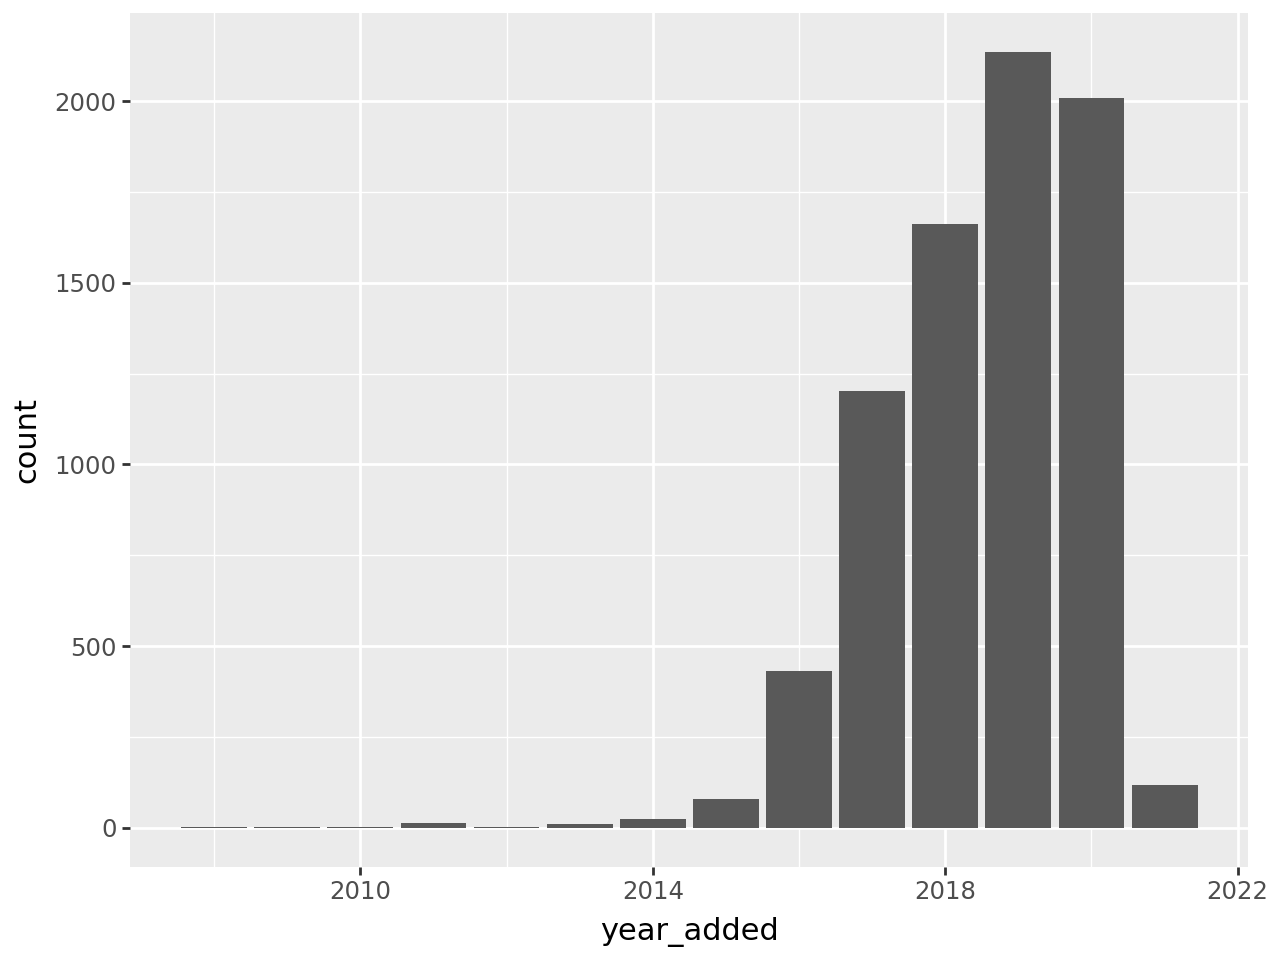

In [253]:
count_per_date["year_added"] = count_per_date["date_added"].dt.year 
count_per_year_added = count_per_date.groupby(by = "year_added").agg({"count":"sum"}).reset_index()

ggplot(count_per_year_added, aes(x="year_added",y="count")) + geom_col()

Show the same but making a distinction betewwn Movies and TV Shows (column `type`).

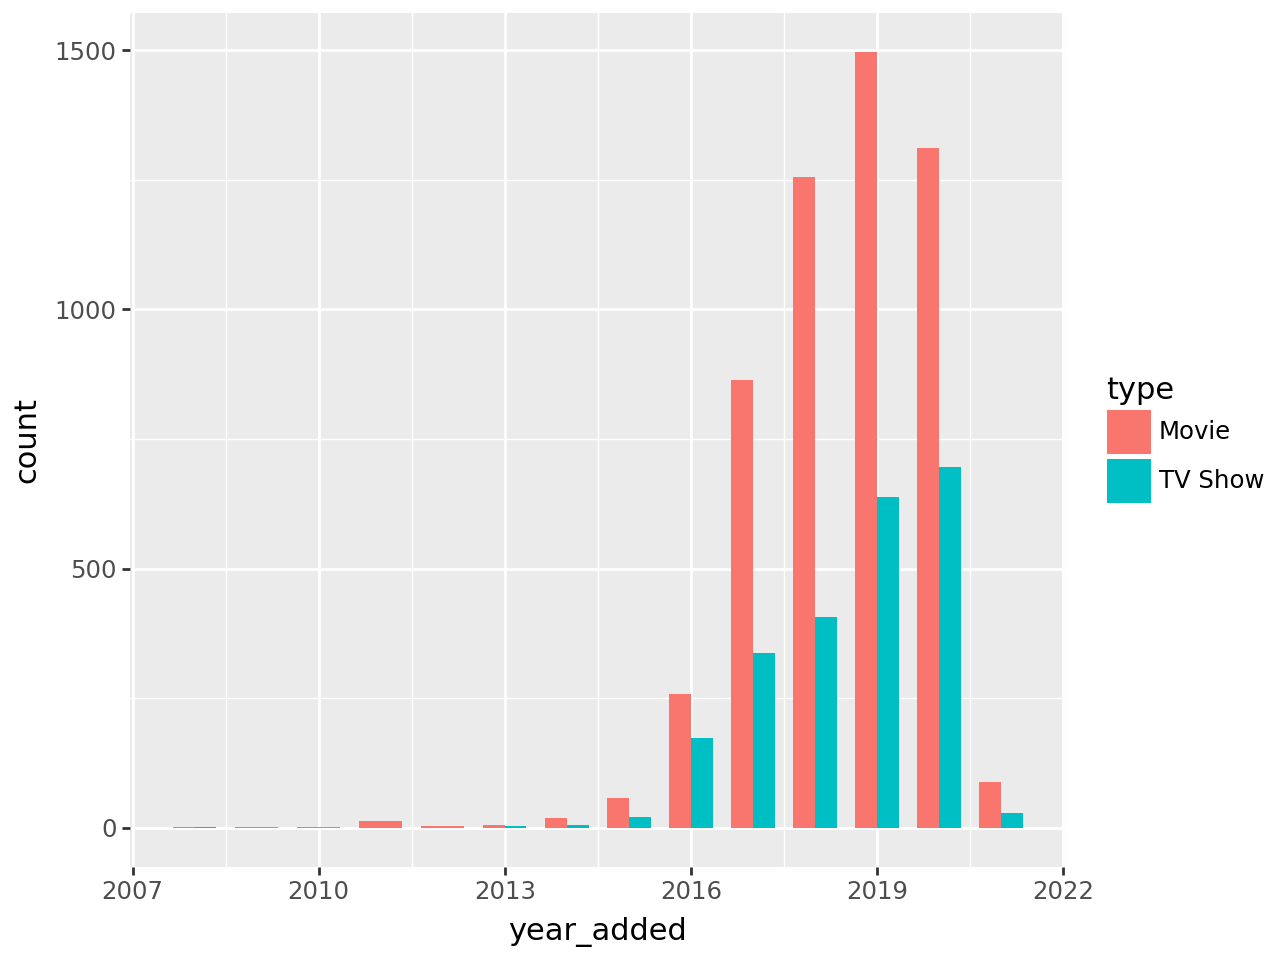

In [254]:
titles_per_year = (
    netflix
    .assign(year_added=lambda d: d["date_added"].dt.year)
    .groupby(["year_added", "type"], as_index=False)
    .agg(count=("show_id", "count"))
)

(
    ggplot(titles_per_year, aes(x="year_added", y="count", fill="type"))
    + geom_col(width = 0.7, position = "dodge")
)


## Movie duration

Show distribution of movie duration

c:\Users\matte\Desktop\PoliTo\Data Science and  Visualization\repo_singole_labs\dsv-lab-4\.venv\Lib\site-packages\plotnine\stats\stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 97'. Pick better value with 'binwidth'.


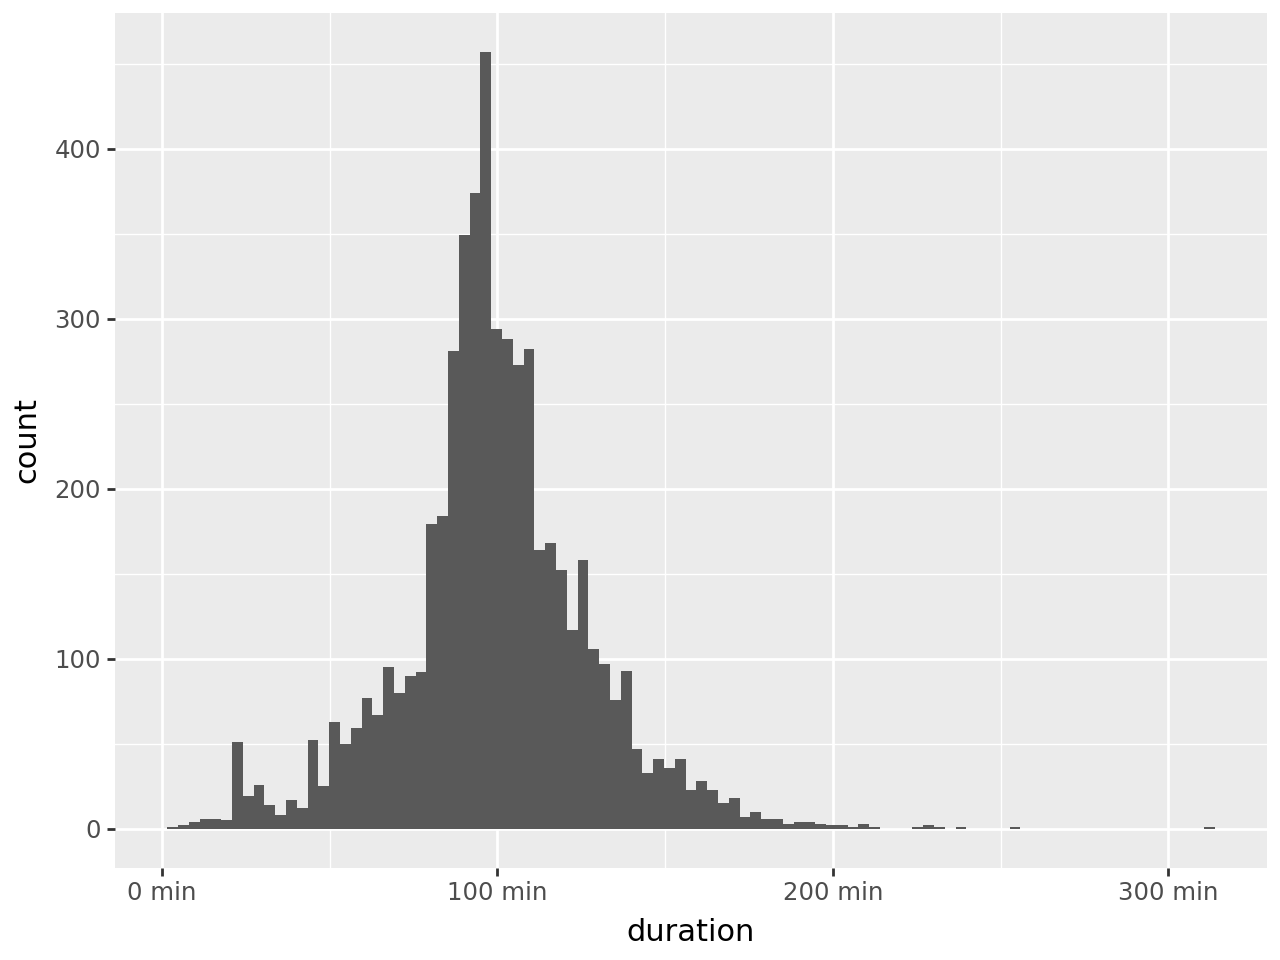

In [255]:
movie_duration = netflix.query("type=='Movie'")["duration"]
movie_duration = pd.to_timedelta(movie_duration, errors="coerce").reset_index()

ggplot(movie_duration, aes(x="duration")) + geom_histogram()

Show correlation of movie duration and year of release

In [256]:
duration_year = netflix.query("type=='Movie'")
duration_year["duration"] = (
    duration_year["duration"]
    .apply(lambda x: int(x.split(" ")[0]))
    .convert_dtypes()
)
correlation = duration_year["duration"].corr(duration_year["release_year"], method="pearson")
print(f"Pearson correlation (duration_min vs release_year): {correlation:.3f}")

Pearson correlation (duration_min vs release_year): -0.205


## Genres

Show the number of titles per genre (column `listed_in`) as horizontal bars.

Note that many values can appear separated by `", "`, thus you need to use the string method `split()`

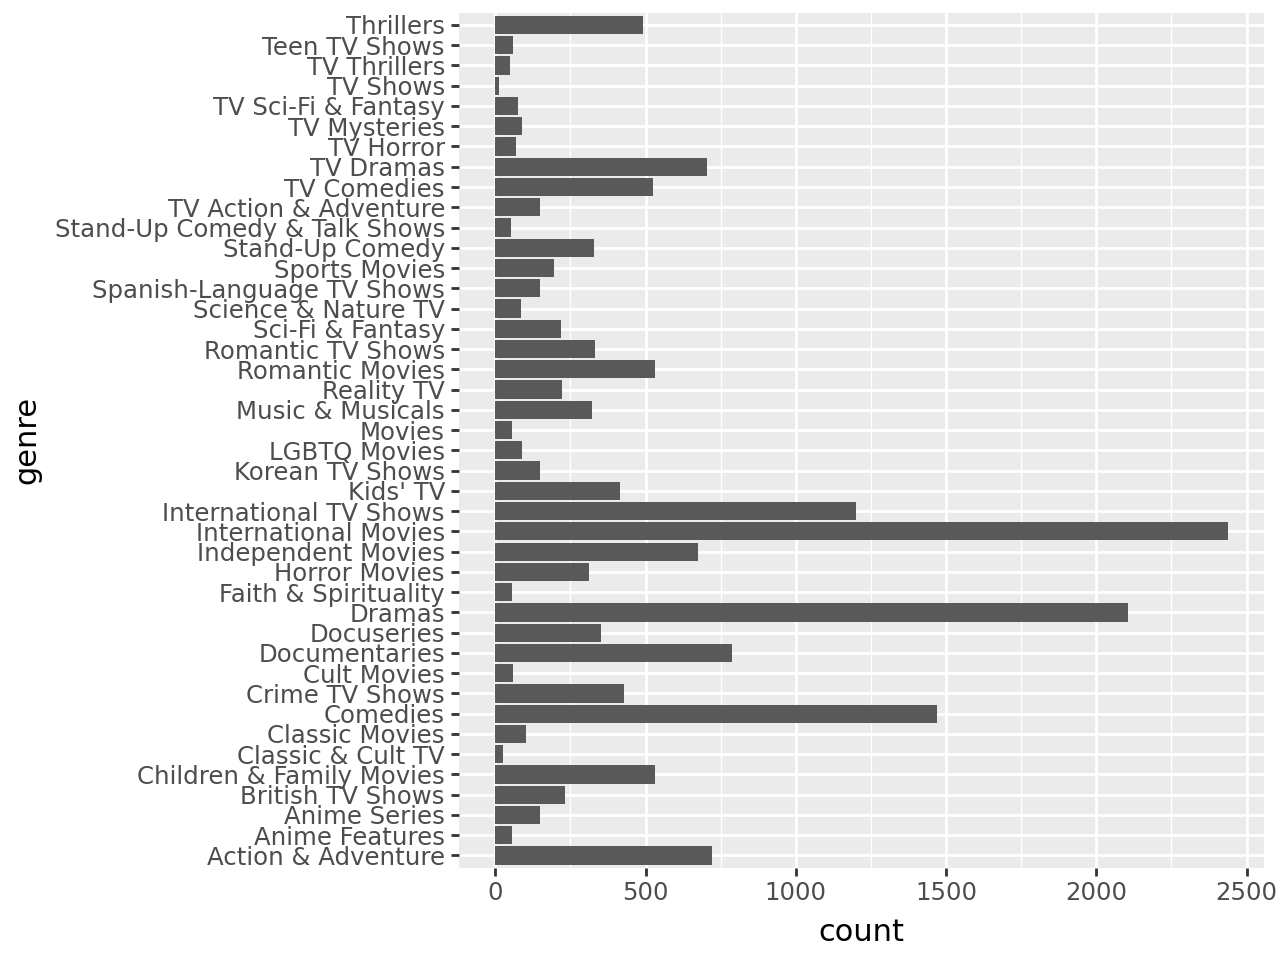

In [257]:
expanded_genres_listing = netflix["listed_in"].apply(lambda x: x.split(", ")).explode().to_frame()
genre_counter = expanded_genres_listing.value_counts().reset_index().rename(columns={"listed_in":"genre"})

ggplot(genre_counter, aes(x="genre",y="count")) + geom_col() + coord_flip()

The method `value_counts()` sort by descending count, but the elements on the axis (sinche they are strings) are placed in alphabetical order.

Order the genres by count (hint: use a categorical type)

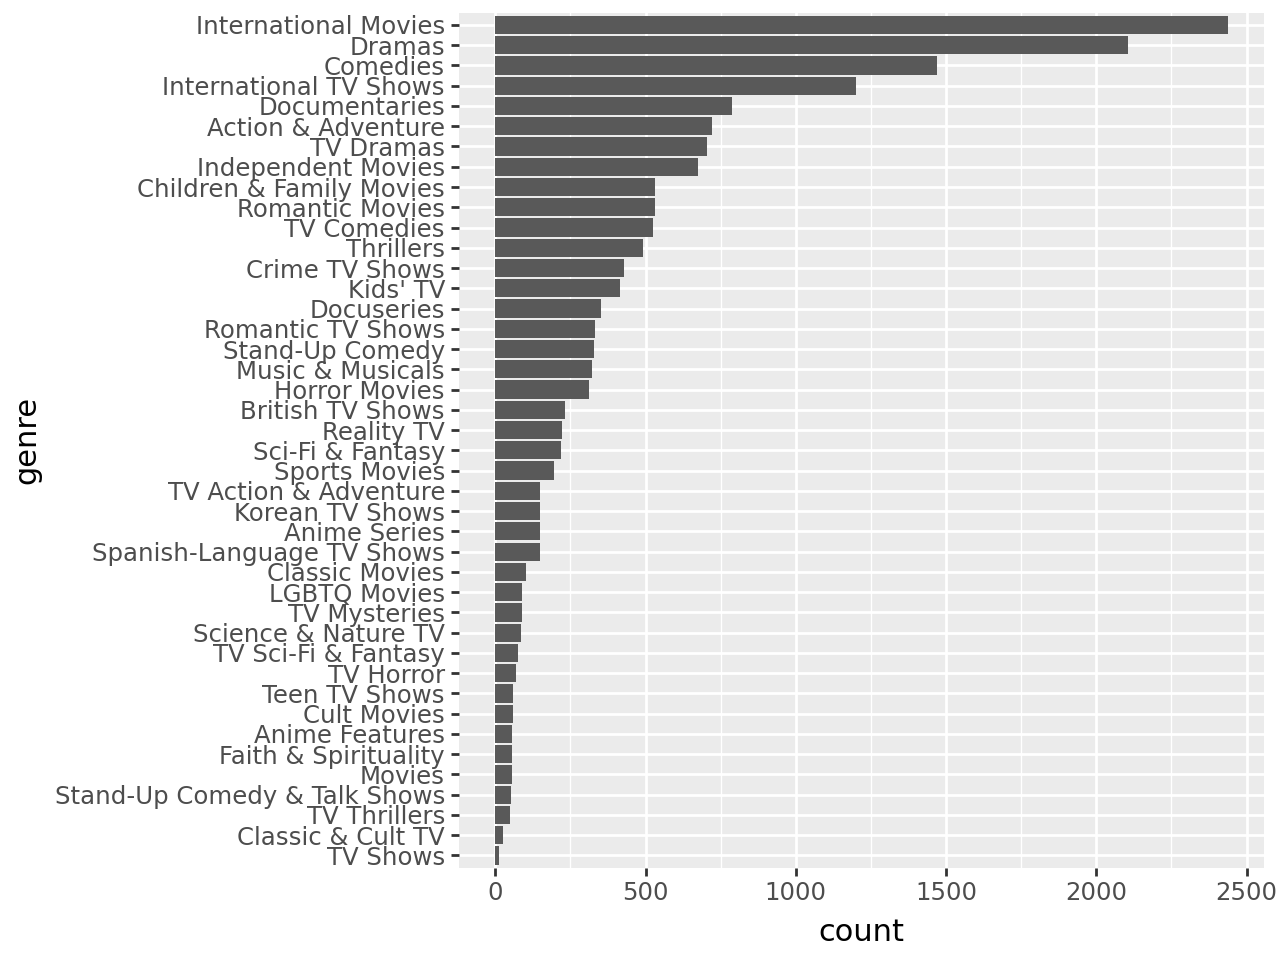

In [258]:
genre_counter = genre_counter.sort_values(by="count",ascending=True)

genre_counter["genre"] = pd.Categorical(
    values = genre_counter["genre"],
    categories = genre_counter["genre"],
    ordered = True
)

(
    ggplot(genre_counter, aes(x="genre",y="count"))
    + geom_col()
    + coord_flip()
)